<a href="https://colab.research.google.com/github/Eritriharyanto/mushroom-classification/blob/main/Jamur_2_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mushroom Classification**
**Attribute Information:**
*   (classes: edible=e, poisonous=p)
*   cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

*   cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
*   cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

*   bruises: bruises=t,no=f

*   odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

*   gill-attachment: attached=a,descending=d,free=f,notched=n

*   gill-spacing: close=c,crowded=w,distant=d

*   gill-size: broad=b,narrow=n

*   gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

*   stalk-shape: enlarging=e,tapering=t
*   stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?


*   stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s


*   stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s


*   stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y


*   stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y


*   veil-type: partial=p,universal=u


*   veil-color: brown=n,orange=o,white=w,yellow=y

*   ring-number: none=n,one=o,two=t

*   ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z


*   spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y


*   population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

*   habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

# **Import**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Load

In [ ]:
df = pd.read_csv("mushrooms.csv")

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# EDA

In [ ]:
print("Jumlah Baris dan Kolom")
print(df.shape)

print("\nInformasi Dataset")
df.info()



Jumlah Baris dan Kolom
(8124, 23)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring 

**cek missing value**

In [ ]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


**cek jumlah "?"**

In [ ]:
(df == '?').sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


**mengganti isi "?" dengan unkwown**

In [ ]:
df['stalk-root'] = df['stalk-root'].replace('?', 'Unknown')

print(df['stalk-root'].value_counts())


stalk-root
b          3776
Unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64


**cek kelas edible=e, poisonous=p**

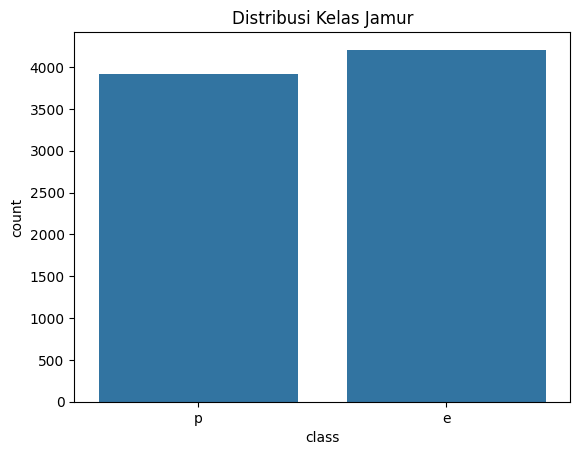

In [ ]:
sns.countplot(
    x='class',
    data=df
)

plt.title("Distribusi Kelas Jamur")
plt.show()

# **Pra-pemrosesan Data**

**label encoding**

In [ ]:
le_dict = {}

for col in df.columns:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    le_dict[col] = le

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


**pemisah fitur dan target**

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

print(X.shape)
print(y.shape)

(8124, 22)
(8124,)


**train dan test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (6499, 22)
Test  : (1625, 22)


**standarisasi data**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Model**

**build**

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# **Evaluasi**

**Classification Report**

In [ ]:
results = []

for name, model in models.items():

    X_tr, X_te = (
        (X_train_scaled, X_test_scaled)
        if name == "Logistic Regression"
        else
        (X_train, X_test)
    )

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

    print("="*50)
    print(name)
    print(f"Accuracy : {acc:.4f}")
    print(classification_report(
        y_test,
        y_pred
    ))

Random Forest
Accuracy : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Logistic Regression
Accuracy : 0.9625
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       842
           1       0.96      0.96      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



**result**

In [ ]:
result_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

result_df = result_df.sort_values(
    by="Accuracy",
    ascending=False
).round(4)

result_df

,Model,Accuracy
0,Random Forest,1.0000
1,Logistic Regression,0.9625


**bar chart akurasi**

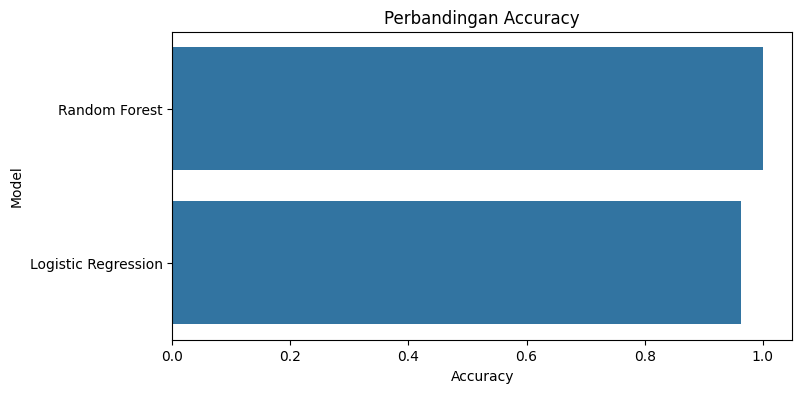

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=result_df,
    x="Accuracy",
    y="Model"
)

plt.title("Perbandingan Accuracy")
plt.show()

**cross validation**

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    model_cv = (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        if name == "Logistic Regression"
        else model
    )

    scores = cross_val_score(
        model_cv,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "CV Accuracy", "Std"]
)

cv_df = cv_df.sort_values(
    "CV Accuracy",
    ascending=False
).round(4)

cv_df

,Model,CV Accuracy,Std
0,Random Forest,1.0000,0.0000
1,Logistic Regression,0.9558,0.0058


**confusion matrix random forest**

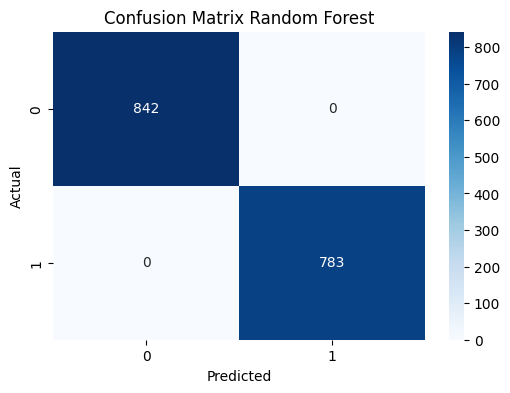

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix Random Forest'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**confusion matrix logistik regression**

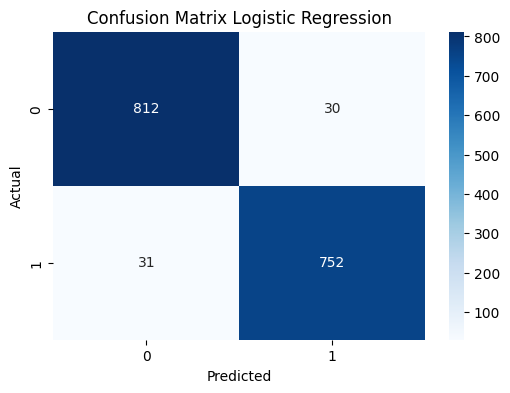

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

cm = confusion_matrix(
    y_test,
    lr.predict(X_test_scaled)
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**ROC**

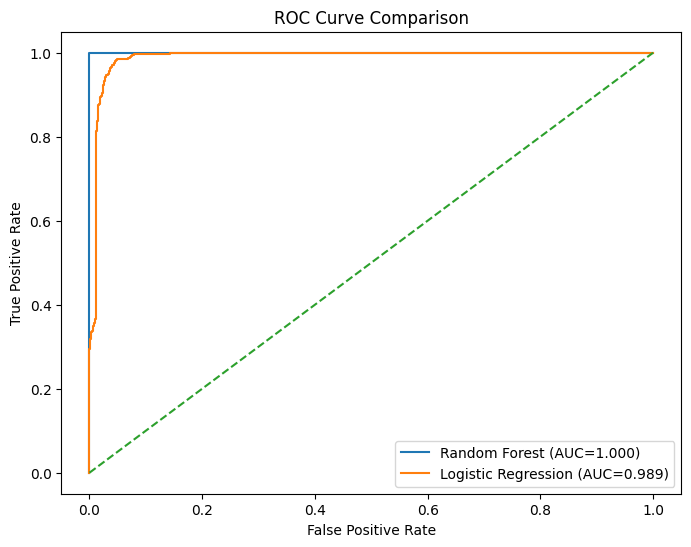

In [ ]:
plt.figure(figsize=(8,6))

roc_models = {
    "Random Forest": (
        rf,
        X_train,
        X_test
    ),
    "Logistic Regression": (
        lr,
        X_train_scaled,
        X_test_scaled
    )
}

for name, (model, X_tr, X_te) in roc_models.items():
    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

**fitur penting**

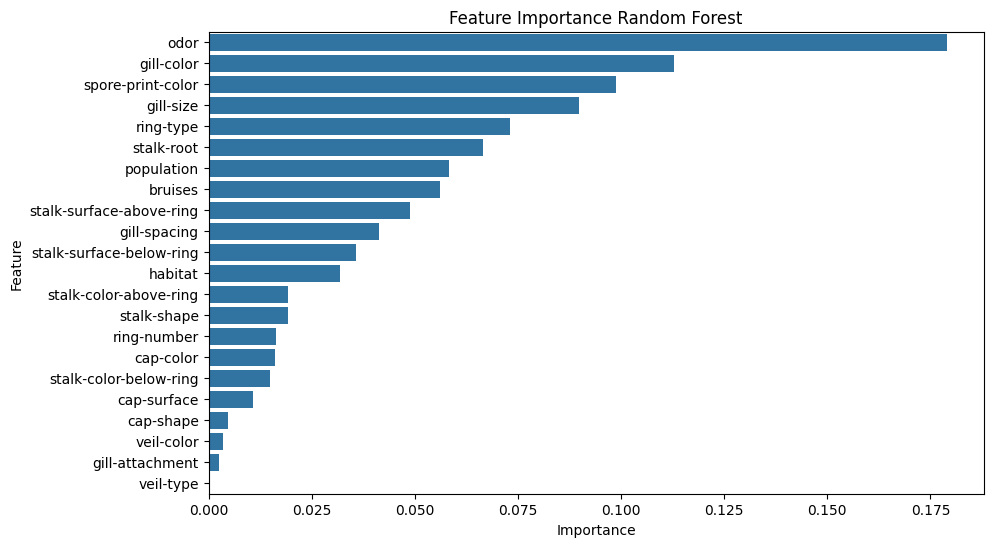

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance Random Forest'
)

plt.show()

**final**

In [ ]:
train_test_results = []

for name, model in models.items():

    X_tr, X_te = (
        (X_train_scaled, X_test_scaled)
        if name == "Logistic Regression"
        else
        (X_train, X_test)
    )

    model.fit(X_tr, y_train)

    train_test_results.append([
        name,
        accuracy_score(y_train, model.predict(X_tr)),
        accuracy_score(y_test, model.predict(X_te))
    ])

train_test_df = pd.DataFrame(
    train_test_results,
    columns=["Model", "Train Accuracy", "Test Accuracy"]
)

train_test_df = train_test_df.sort_values(
    "Test Accuracy",
    ascending=False
).round(4)

train_test_df

,Model,Train Accuracy,Test Accuracy
0,Random Forest,1.0000,1.0000
1,Logistic Regression,0.9575,0.9625
